# Multiclass Classification

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions


In [2]:
dataset=pd.read_csv(r"C:\Users\Ruhan\Downloads\iris_5000_rows.csv")
dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,7.1,3.0,5.9,2.1,virginica
1,5.8,2.6,4.0,1.2,versicolor
2,5.8,4.0,1.2,0.2,setosa
3,4.9,2.5,4.5,1.7,virginica
4,6.1,2.8,4.0,1.3,versicolor


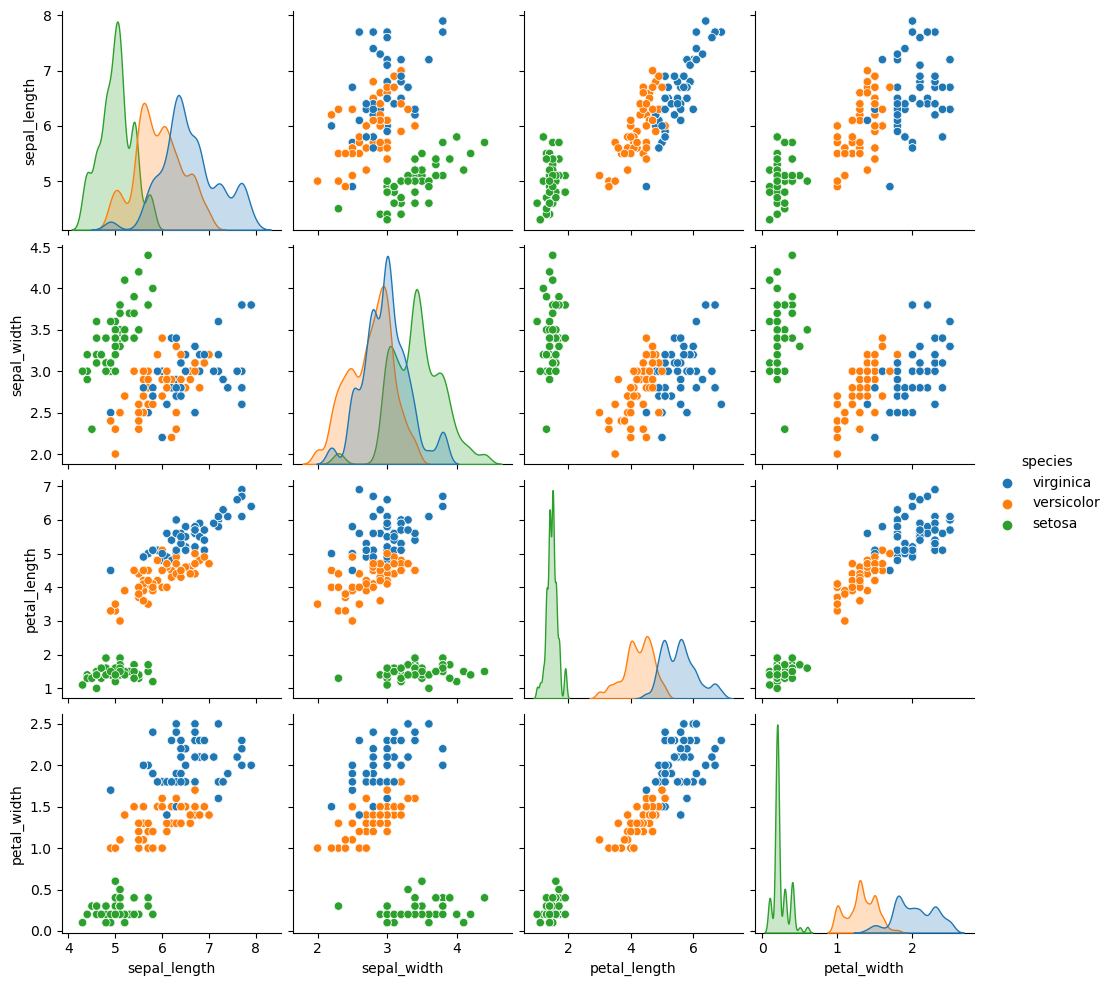

In [3]:
sns.pairplot(data=dataset,hue="species")
plt.show()

In [4]:
x=dataset.iloc[:,:-1]
y=dataset["species"]multi_class="ovr"

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Ovr method

In [6]:
lr=LogisticRegression(multi_class="ovr")
lr.fit(x_train,y_train)

C:\Users\Ruhan\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [7]:
lr.score(x_test,y_test)

0.968

# multinomial method

In [8]:
lr1=LogisticRegression(multi_class="multinomial")
lr1.fit(x_train,y_train)

C:\Users\Ruhan\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Ruhan\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [9]:
lr1.score(x_test,y_test)

0.983

# Confusion matrix
sometimes 95% accuracy model is also rejected because of typeII error and this in checked by confusion metrics
typeI error is when the actual value is false model predict true also known as false positive 
typeII error is when the actual value is true and model predict false also known as false negative  
if most of the wrong prediction is typeII error then model is rejected


In [10]:
dataset=pd.read_csv("netflix_dataset_2_features.csv")
dataset.head(3)

,age,monthly_income,netflix
0,56,72733,0
1,46,85318,0
2,32,174736,1


In [11]:
x=dataset.iloc[:,:-1]
y=dataset["netflix"]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score

In [15]:
cf=confusion_matrix(y_test,lr.predict(x_test))
cf

array([[17,  4],
       [ 0, 19]], dtype=int64)

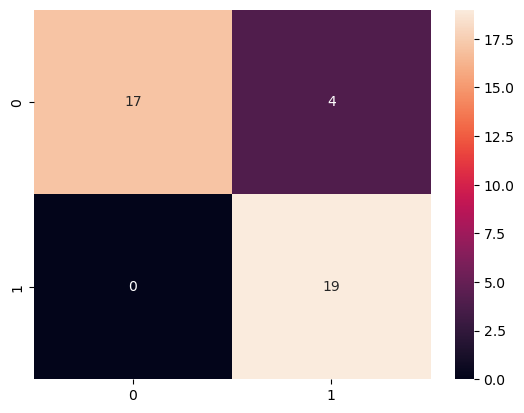

In [16]:
sns.heatmap(cf,annot=True)
plt.show()

Recall is tp/(tp+fn) , precision is tp/(tp+fp) , f1_score = 2*(recall*precision)/(recall+precision)
sometimes we have to have good recall some times precision and 
when we donot know much about dataset we have to make f1_score better in order make our model better 
f1 is also know as harmonic mean of recall and precision

In [17]:
precision_score(y_test,lr.predict(x_test))*100

82.6086956521739

In [18]:
recall_score(y_test,lr.predict(x_test))*100

100.0

In [19]:
f1_score(y_test,lr.predict(x_test))*100

90.47619047619048

C:\Users\Ruhan\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


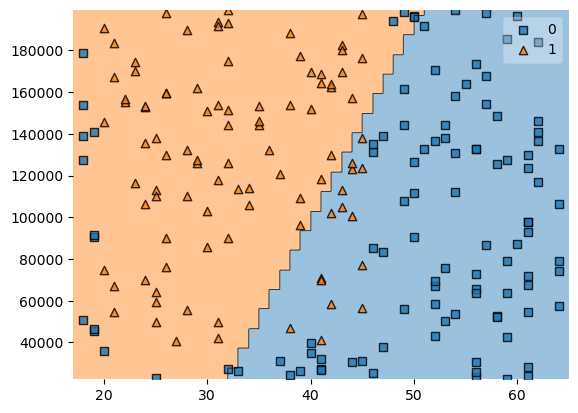

In [22]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=lr)
plt.show()